In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from core.data import load_from_kaggle
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter
from collections import defaultdict

c:\Users\yamen\Desktop\Weiterbildung\visual Studio Code\mein-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_link = "saireddypothireddy/human-data-sequence-dataset" # replace with your dataset link from Kaggle 
destination = "../../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

Destination directory '../../data/raw\human-data-sequence-dataset' already exists with files. Skipping download (replace=False).


In [3]:
files

['Human Data Sequnence.txt']

In [4]:
my_path = "../../data/raw/human-data-sequence-dataset/Human Data Sequnence.txt"
with open(my_path, "r") as f:
    file = f.read()
file[:500]

'sequence\tclass\nATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCATACTCCTTACACTATTCCTCATCACCCAACTAAAAATATTAAACACAAACTACCACCTACCTCCCTCACCAAAGCCCATAAAAATAAAAAATTATAACAAACCCTGAGAACCAAAATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG\t4\nATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAGGCCTACCCGCCGCAGTACTGATCATTCTATTTCCCCCTCTATTGATCCCCACCTCCAAATATCTCATCAACAACCGACTAATCACCACCCAACAATGACTAATCAAACTAACCTCAAAACAAATGATAACCATACACAACACTAAAGGACGAACCTGATCTCTTATACTAGTATCCTTAATCATTTTTATTGCCACAACTAACCTCCTCGGACTCCTGCCTCACTCATT'

In [5]:
df = pd.read_csv(my_path, sep='\t')
sequences = df["sequence"].values
df.head()

,sequence,class
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,4
1,ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...,4
2,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3
3,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3
4,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,3


In [6]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })


'Shape'

(4380, 2)

'Description'

,count,mean,std,min,25%,50%,75%,max
class,4380.0,3.5,2.13,0.0,2.0,4.0,6.0,6.0


'Duplicates'

np.int64(751)

,Data Types,Missing Values,Unique Values,Sample Values
sequence,object,0,3629,[ATGGATGGGTCAAACGTGACATCATTTGTTGTTGAGGAACCCACG...
class,int64,0,7,"[3, 3, 6]"


In [7]:
#Deal with duplicates
sequences = df['sequence'].values
seq_to_indices = defaultdict(list)

for i, seq in enumerate(sequences):
    seq_to_indices[seq].append(i)

duplicates = {seq: idxs for seq, idxs in seq_to_indices.items() if len(idxs) > 1}

print(f"Anzahl exakter Duplikate: {len(duplicates)}")

Anzahl exakter Duplikate: 489


In [8]:
#search the best k-mer value for clustering
for k in [3, 4, 5]:
    vectorizer = CountVectorizer(analyzer="char", ngram_range=(k, k))
    X = vectorizer.fit_transform(sequences)
    X_scaled = StandardScaler(with_mean=False).fit_transform(X)
    clusters = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_scaled)
    score = silhouette_score(X_scaled, clusters)
    print(f"k-mer={k}, silhouette={score:.3f}")

k-mer=3, silhouette=0.373
k-mer=4, silhouette=0.315
k-mer=5, silhouette=0.267


In [9]:
#K-mer Feature Extraction
k = 3 
vectorizer = CountVectorizer(analyzer="char", ngram_range=(k, k))
X = vectorizer.fit_transform(sequences)

scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X)

n_clusters = 3
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)
df["cluster"] = clusters
display(df)

,sequence,class,cluster
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,4,0
1,ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...,4,0
2,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,1
3,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,0
4,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,3,1
...,...,...,...
4375,ATGGAAGATTTGGAGGAAACATTATTTGAAGAATTTGAAAACTATT...,0,0
4376,ATGCAGTCCTTTCGGGAGCAAAGCAGTTACCACGGAAACCAGCAAA...,6,2
4377,ATGCAGTCCTTTCGGGAGCAAAGCAGTTACCACGGAAACCAGCAAA...,6,2
4378,ATGGGGCACCTGGTTTGCTGTCTGTGTGGCAAGTGGGCCAGTTACC...,6,0


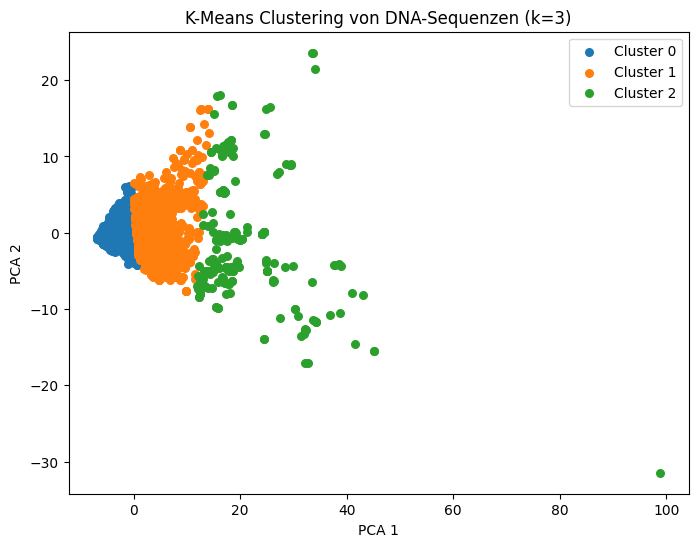

In [10]:
#PCA zur Visualisierung
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled.toarray())
unique_clusters = np.unique(clusters)
plt.figure(figsize=(8, 6))

for cluster_id in unique_clusters:
    idx=clusters==cluster_id
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        s=30,
        label=f"Cluster {cluster_id}"
    )
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clustering von DNA-Sequenzen (k=3)")
plt.legend()
plt.show()

In [24]:
feature_names = vectorizer.get_feature_names_out()
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=["PC1", "PC2"])

pc1_top_pos = loadings["PC1"].sort_values(ascending=False).head(10)
pc1_top_neg = loadings["PC1"].sort_values().head(10)

pc2_top_pos = loadings["PC2"].sort_values(ascending=False).head(10)
pc2_top_neg = loadings["PC2"].sort_values().head(10)

ca=ca = pd.DataFrame({
    "PCA1_pos_kmer": pc1_top_pos.index,
    "PCA1_pos_loading": pc1_top_pos.values,
    "PCA1_neg_kmer": pc1_top_neg.index,
    "PCA1_neg_loading": pc1_top_neg.values,
    "PCA2_pos_kmer": pc2_top_pos.index,
    "PCA2_pos_loading": pc2_top_pos.values,
    "PCA2_neg_kmer": pc2_top_neg.index,
    "PCA2_neg_loading": pc2_top_neg.values,
})

ca.head(10)

,PCA1_pos_kmer,PCA1_pos_loading,PCA1_neg_kmer,PCA1_neg_loading,PCA2_pos_kmer,PCA2_pos_loading,PCA2_neg_kmer,PCA2_neg_loading
0,tca,0.136402,nag,-0.009849,cgc,0.242290,taa,-0.194211
1,gga,0.136206,nng,-0.009385,ccg,0.237585,tta,-0.190739
2,cat,0.135930,ntg,-0.007721,cgg,0.236157,ata,-0.190125
3,atc,0.135574,nnc,-0.007550,gcg,0.236032,att,-0.181355
4,tga,0.135415,ngg,-0.007430,gcc,0.195143,aat,-0.177705
5,atg,0.135307,nna,-0.006808,ccc,0.194590,aaa,-0.175141
6,gtc,0.135210,nga,-0.006724,ggc,0.193493,tat,-0.167967
7,gac,0.135128,ngc,-0.006584,ggg,0.164733,ttt,-0.166446
8,tgg,0.134979,nnt,-0.005979,acg,0.163878,tag,-0.155458
9,aca,0.134947,nac,-0.005463,cgt,0.151267,ttg,-0.133232


In [12]:
#DNA classification
#calculation of Sequence_Length, A_freq, C_freq, G_freq, T_freq, GC_Content
def global_features(seq):
    length = len(seq)
    counts = Counter(seq)

    a = counts.get("A", 0) / length
    c = counts.get("C", 0) / length
    g = counts.get("G", 0) / length
    t = counts.get("T", 0) / length
    gc = g + c

    return [length, a, c, g, t, gc]

X_global = np.array([global_features(seq) for seq in sequences])

In [13]:
#create of new columns by dataphram
df['seq_length'] = X_global[:, 0]
df['A_freq'] = X_global[:, 1]
df['C_freq'] = X_global[:, 2]
df['G_freq'] = X_global[:, 3]
df['T_freq'] = X_global[:, 4]
df['GC_content'] = X_global[:, 5]
display(df)

,sequence,class,cluster,seq_length,A_freq,C_freq,G_freq,T_freq,GC_content
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,4,0,207.0,0.386473,0.333333,0.062802,0.217391,0.396135
1,ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...,4,0,681.0,0.302496,0.337739,0.104258,0.255507,0.441997
2,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,1,1686.0,0.282325,0.198102,0.233096,0.286477,0.431198
3,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,0,1206.0,0.281095,0.174129,0.243781,0.300995,0.417910
4,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,3,1,1437.0,0.290188,0.200418,0.226862,0.282533,0.427279
...,...,...,...,...,...,...,...,...,...
4375,ATGGAAGATTTGGAGGAAACATTATTTGAAGAATTTGAAAACTATT...,0,0,57.0,0.385965,0.105263,0.192982,0.315789,0.298246
4376,ATGCAGTCCTTTCGGGAGCAAAGCAGTTACCACGGAAACCAGCAAA...,6,2,5883.0,0.278259,0.262111,0.258882,0.200748,0.520993
4377,ATGCAGTCCTTTCGGGAGCAAAGCAGTTACCACGGAAACCAGCAAA...,6,2,5817.0,0.279354,0.259584,0.259240,0.201822,0.518824
4378,ATGGGGCACCTGGTTTGCTGTCTGTGTGGCAAGTGGGCCAGTTACC...,6,0,753.0,0.252324,0.258964,0.292165,0.196547,0.551129


In [14]:
#calculation of kmer3_freq
k = 3
vectorizer = CountVectorizer(
    analyzer="char",
    ngram_range=(k, k)
)

X_kmer = vectorizer.fit_transform(sequences).toarray()

# Normierung auf Sequenzlänge
X_kmer = X_kmer / X_kmer.sum(axis=1, keepdims=True)
df['kmer3_freq_mean'] = X_kmer.mean()
df

,sequence,class,cluster,seq_length,A_freq,C_freq,G_freq,T_freq,GC_content,kmer3_freq_mean
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,4,0,207.0,0.386473,0.333333,0.062802,0.217391,0.396135,0.011905
1,ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...,4,0,681.0,0.302496,0.337739,0.104258,0.255507,0.441997,0.011905
2,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,1,1686.0,0.282325,0.198102,0.233096,0.286477,0.431198,0.011905
3,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,0,1206.0,0.281095,0.174129,0.243781,0.300995,0.417910,0.011905
4,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,3,1,1437.0,0.290188,0.200418,0.226862,0.282533,0.427279,0.011905
...,...,...,...,...,...,...,...,...,...,...
4375,ATGGAAGATTTGGAGGAAACATTATTTGAAGAATTTGAAAACTATT...,0,0,57.0,0.385965,0.105263,0.192982,0.315789,0.298246,0.011905
4376,ATGCAGTCCTTTCGGGAGCAAAGCAGTTACCACGGAAACCAGCAAA...,6,2,5883.0,0.278259,0.262111,0.258882,0.200748,0.520993,0.011905
4377,ATGCAGTCCTTTCGGGAGCAAAGCAGTTACCACGGAAACCAGCAAA...,6,2,5817.0,0.279354,0.259584,0.259240,0.201822,0.518824,0.011905
4378,ATGGGGCACCTGGTTTGCTGTCTGTGTGGCAAGTGGGCCAGTTACC...,6,0,753.0,0.252324,0.258964,0.292165,0.196547,0.551129,0.011905


In [15]:
labels = []
with open(my_path, "r") as f:
    f.readline()  # Header
    for line in f:
        seq, cls = line.strip().split("\t")
        labels.append(int(cls))

In [16]:
X = np.hstack([X_global, X_kmer])
y = np.array(labels)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84       106
           1       0.94      0.74      0.83       107
           2       0.98      0.59      0.73        70
           3       0.86      0.78      0.82       134
           4       0.73      0.77      0.75       142
           5       1.00      0.69      0.81        48
           6       0.75      0.96      0.84       269

    accuracy                           0.81       876
   macro avg       0.87      0.76      0.80       876
weighted avg       0.83      0.81      0.81       876



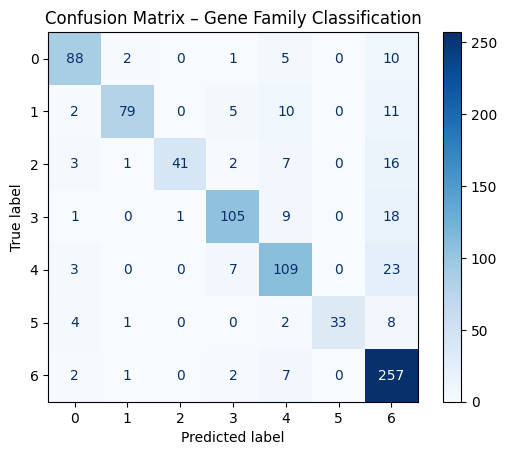

In [17]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix – Gene Family Classification")
plt.show()

<Figure size 1000x500 with 0 Axes>

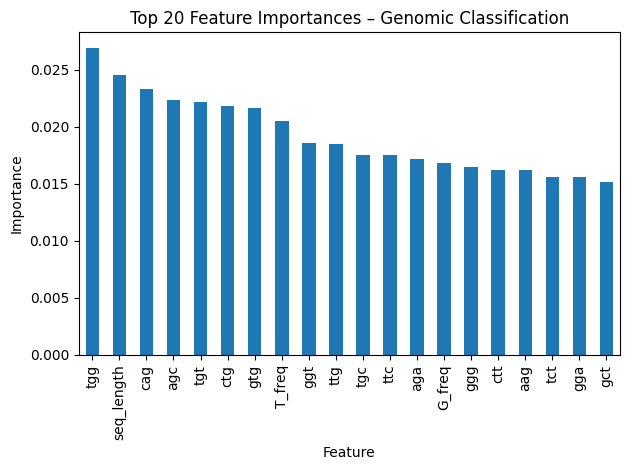

In [18]:
global_feature_names = [
    "seq_length",
    "A_freq",
    "C_freq",
    "G_freq",
    "T_freq",
    "GC_content"
]
kmer_feature_names = vectorizer.get_feature_names_out()
feature_names = global_feature_names + list(kmer_feature_names)

importances = clf.feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 5))

fi.iloc[:20].plot(
    x="feature",
    y="importance",
    kind="bar",
    legend=False
)

plt.ylabel("Importance")
plt.xlabel("Feature")
plt.title("Top 20 Feature Importances – Genomic Classification")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [19]:
X_df = pd.DataFrame(X, columns=feature_names)
X_df["label"] = y

mean_features = X_df.groupby("label").mean()

mean_features_20 = mean_features.loc[6].sort_values(ascending=False).iloc[:20]
mean_features_20

seq_length    1128.495905
GC_content       0.534430
C_freq           0.271812
A_freq           0.264352
G_freq           0.262618
T_freq           0.200854
cag              0.032977
cca              0.026087
aga              0.025962
ctg              0.024934
ccc              0.024913
agc              0.024713
gaa              0.024479
aag              0.024118
gga              0.023686
gcc              0.022875
gag              0.022728
tgg              0.021674
cct              0.021408
gca              0.021229
Name: 6, dtype: float64

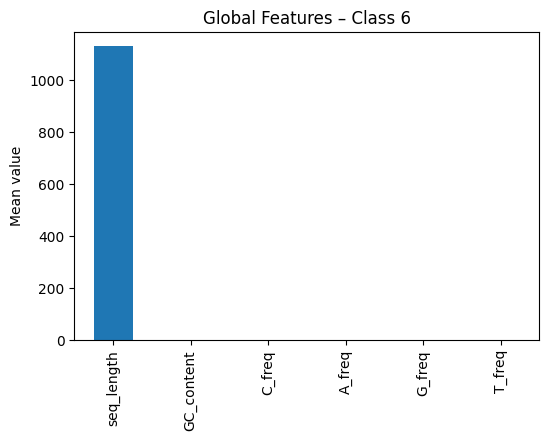

In [20]:
global_feats = [
    "seq_length", "A_freq", "C_freq", "G_freq", "T_freq", "GC_content"
]

mean_global_6 = mean_features.loc[6].sort_values(ascending=False).iloc[:6]

mean_global_6.plot(kind="bar", figsize=(6,4))
plt.title("Global Features – Class 6")
plt.ylabel("Mean value")
plt.show()

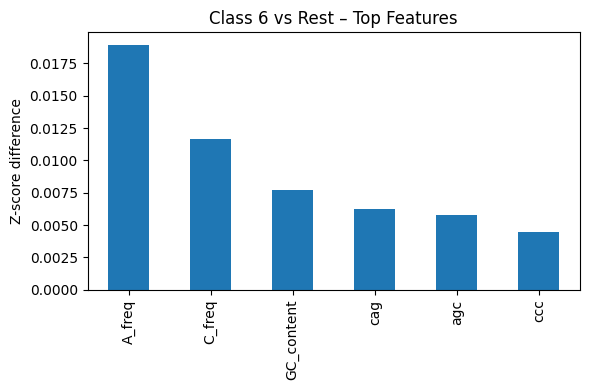

In [21]:
mean_6 = mean_features.loc[6]
mean_rest = mean_features.drop(6).mean()

diff = (mean_6 - mean_rest).sort_values(ascending=False).iloc[:6]
plt.figure(figsize=(6,4))
diff.plot(kind="bar")
plt.ylabel("Z-score difference")
plt.title("Class 6 vs Rest – Top Features")
plt.tight_layout()

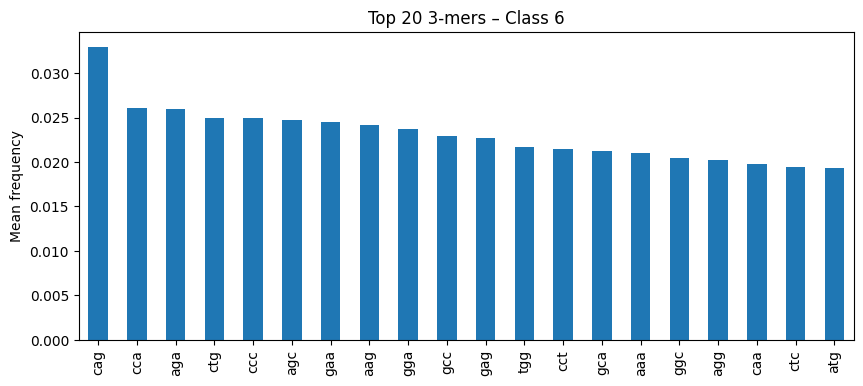

In [22]:
kmer_feats = [f for f in mean_features.columns if len(f) == 3]

mean_kmer_6 = mean_features.loc[6][kmer_feats].sort_values(ascending=False).iloc[:20]

mean_kmer_6.plot(kind="bar", figsize=(10,4))
plt.title("Top 20 3-mers – Class 6")
plt.ylabel("Mean frequency")
plt.xticks(rotation=90)
plt.show()